In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import genpareto, chi2
import yfinance as yf
import matplotlib.pyplot as plt


In [ ]:
ticker = 'XLF'
data = yf.download(ticker, start='2010-01-01', end='2024-04-10')['Close']
returns = data.pct_change().dropna()

# Convert returns to losses
losses = -returns  # So big negative returns become positive losses

# Set threshold and compute exceedances
threshold = np.percentile(losses, 95)
exceedances = (losses[losses > threshold] - threshold).to_numpy().ravel()

# Drop any NaNs or Infs (in case slicing caused NaNs)
exceedances = exceedances[np.isfinite(exceedances)]

# Fit GPD to exceedances
params = genpareto.fit(exceedances)
shape, loc, scale = params
print(f"GPD Parameters:\nShape (ξ): {shape:.4f}, Scale (β): {scale:.4f}")


# Estimate VaR and ES at 99%
p = 0.99
n = len(losses)
nu = len(exceedances)

VaR_99 = threshold + (scale / shape) * (((n / nu * (1 - p)) ** (-shape)) - 1)

if shape < 1:
    ES_99 = (VaR_99 + (scale - shape * threshold)) / (1 - shape)
else:
    ES_99 = np.inf  # ES does not exist when shape ≥ 1

print(f"\nEstimated GPD VaR (99%): {VaR_99:.4%}")
print(f"Estimated GPD ES  (99%): {ES_99:.4%}")



YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

GPD Parameters:
Shape (ξ): 0.5175, Scale (β): 0.0077

Estimated GPD VaR (99%): 4.0613%
Estimated GPD ES  (99%): 7.7494%


# Static Methods

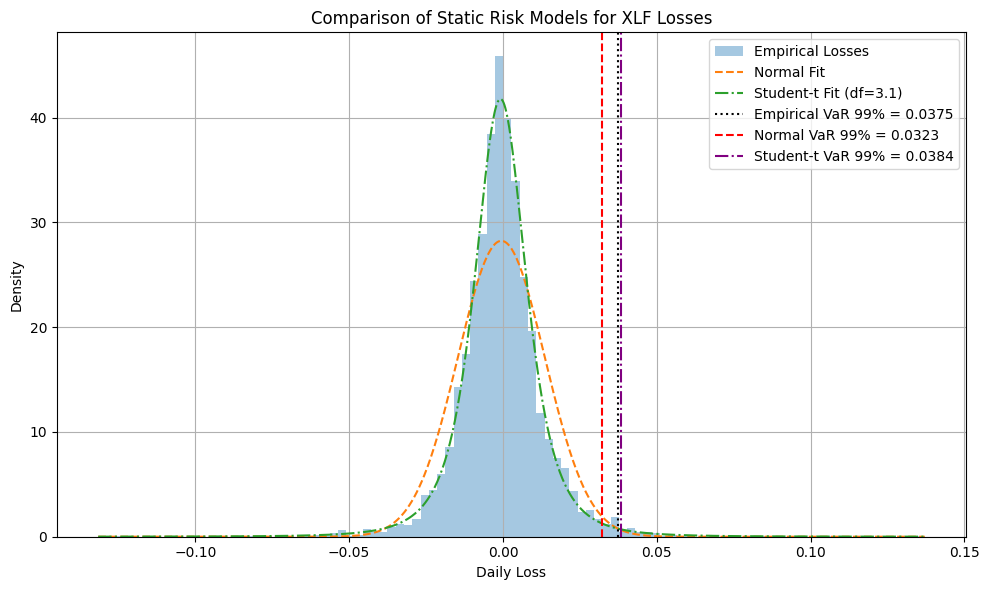

In [ ]:
from scipy.stats import norm, t
import matplotlib.pyplot as plt
import numpy as np

# Convert losses to pure numeric NumPy array
losses = losses.astype(float).dropna().values.flatten()

# Fit Normal and Student-t to losses
mu, sigma = norm.fit(losses)
t_df, t_loc, t_scale = t.fit(losses)

# Set quantile level for VaR
alpha = 0.99
var_normal = norm.ppf(alpha, loc=mu, scale=sigma)
var_t = t.ppf(alpha, df=t_df, loc=t_loc, scale=t_scale)
var_empirical = np.quantile(losses, alpha)

plt.figure(figsize=(10, 6))
x = np.linspace(min(losses), max(losses), 1000)
plt.hist(losses, bins=100, density=True, alpha=0.4, label='Empirical Losses')

plt.plot(x, norm.pdf(x, mu, sigma), label='Normal Fit', linestyle='--')

plt.plot(x, t.pdf(x, df=t_df, loc=t_loc, scale=t_scale), label=f'Student-t Fit (df={t_df:.1f})', linestyle='-.')

# VaR vertical lines
plt.axvline(var_empirical, color='black', linestyle=':', label=f'Empirical VaR 99% = {var_empirical:.4f}')
plt.axvline(var_normal, color='red', linestyle='--', label=f'Normal VaR 99% = {var_normal:.4f}')
plt.axvline(var_t, color='purple', linestyle='-.', label=f'Student-t VaR 99% = {var_t:.4f}')

plt.title("Comparison of Static Risk Models for XLF Losses")
plt.xlabel("Daily Loss")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm, t
from scipy.integrate import quad

# Ensure losses is a numeric array
losses = losses.astype(float)
losses = losses[np.isfinite(losses)].flatten()


# Fit distributions
mu, sigma = norm.fit(losses)
t_df, t_loc, t_scale = t.fit(losses)
alpha = 0.99

# Calculate VaR
var_empirical = np.quantile(losses, alpha)
var_normal = norm.ppf(alpha, loc=mu, scale=sigma)
var_t = t.ppf(alpha, df=t_df, loc=t_loc, scale=t_scale)

# Calculate ES
# ES under Normal distribution
es_normal = mu + sigma * norm.pdf(norm.ppf(alpha)) / (1 - alpha)

# ES under Student-t using numerical integration
def student_t_es(df, loc, scale, alpha=0.99):
    var_t = t.ppf(alpha, df, loc=loc, scale=scale)
    integrand = lambda x: x * t.pdf(x, df, loc=loc, scale=scale)
    integral, _ = quad(integrand, var_t, np.inf)
    return integral / (1 - alpha)

es_t = student_t_es(t_df, t_loc, t_scale, alpha)

# ES from empirical (average of losses above empirical VaR)
es_empirical = losses[losses >= var_empirical].mean()

# Create the summary table
risk_table = pd.DataFrame({
    "Model": ["Empirical", "Normal", "Student-t"],
    "VaR 99%": [var_empirical, var_normal, var_t],
    "ES 99%": [es_empirical, es_normal, es_t]
})

risk_table = risk_table.round(4)

# Display the table
display(risk_table)


,Model,VaR 99%,ES 99%
0,Empirical,0.0375,0.0559
1,Normal,0.0323,0.0371
2,Student-t,0.0384,0.0590


# Loop through the list of tickers (in case for multi-asset extension)


In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.stats import genpareto

# Define your list of tickers (from the paper or your selection)
tickers = ['SPY', 'XLF', 'XLE', 'XOM', 'JPM', 'LMT', 'NEE']

# Store results
results = []

# GPD VaR/ES function per ticker
for ticker in tickers:
    print(f"\n=== Processing: {ticker} ===")

    # Get daily returns
    data = yf.download(ticker, start='2010-01-01', end='2024-04-10')['Close']
    returns = data.pct_change().dropna()

    # Convert to losses (positive tail)
    losses = -returns

    # Set threshold and compute exceedances
    threshold = np.percentile(losses, 95)
    exceedances = (losses[losses > threshold] - threshold).to_numpy().ravel()
    exceedances = exceedances[np.isfinite(exceedances)]  # Clean any NaNs or Infs

    # Fit GPD
    shape, loc, scale = genpareto.fit(exceedances)

    # Estimate VaR and ES at 99%
    p = 0.99
    n = len(losses)
    nu = len(exceedances)
    VaR_99 = threshold + (scale / shape) * (((n / nu) * (1 - p)) ** (-shape) - 1)

    if shape < 1:
        ES_99 = (VaR_99 + (scale - shape * threshold)) / (1 - shape)
    else:
        ES_99 = np.inf

    # Save results
    results.append({
        'Ticker': ticker,
        'GPD Shape (ξ)': shape,
        'GPD Scale (β)': scale,
        'VaR_99': VaR_99,
        'ES_99': ES_99
    })

    # Print individual results
    print(f"GPD Shape: {shape:.4f}, Scale: {scale:.4f}")
    print(f"VaR_99: {VaR_99:.4%}, ES_99: {ES_99:.4%}")


[*********************100%***********************]  1 of 1 completed


=== Processing: SPY ===



[*********************100%***********************]  1 of 1 completed

GPD Shape: 0.1728, Scale: 0.0081
VaR_99: 3.1680%, ES_99: 4.4672%

=== Processing: XLF ===
GPD Shape: 0.5175, Scale: 0.0077
VaR_99: 4.0607%, ES_99: 7.7478%

=== Processing: XLE ===



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

GPD Shape: 0.4363, Scale: 0.0094
VaR_99: 4.7978%, ES_99: 8.1645%

=== Processing: XOM ===
GPD Shape: 0.7140, Scale: 0.0086
VaR_99: 4.8907%, ES_99: 14.3604%

=== Processing: JPM ===



[*********************100%***********************]  1 of 1 completed


GPD Shape: 0.2057, Scale: 0.0108
VaR_99: 4.6486%, ES_99: 6.5387%

=== Processing: LMT ===
GPD Shape: 0.2707, Scale: 0.0085
VaR_99: 3.5662%, ES_99: 5.3643%

=== Processing: NEE ===


[*********************100%***********************]  1 of 1 completed

GPD Shape: 0.7956, Scale: 0.0062
VaR_99: 3.9684%, ES_99: 14.9265%


In [ ]:
gpd_df = pd.DataFrame(results)
print("\n=== GPD VaR/ES Summary Table ===")
print(gpd_df)


=== GPD VaR/ES Summary Table ===
  Ticker  GPD Shape (ξ)  GPD Scale (β)    VaR_99     ES_99
0    SPY       0.172804       0.008134  0.031680  0.044672
1    XLF       0.517505       0.007723  0.040607  0.077478
2    XLE       0.436258       0.009392  0.047978  0.081645
3    XOM       0.714019       0.008563  0.048907  0.143604
4    JPM       0.205720       0.010775  0.046486  0.065387
5    LMT       0.270669       0.008476  0.035662  0.053643
6    NEE       0.795628       0.006208  0.039684  0.149265


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



=== GPD VaR/ES Summary Table ===
  Ticker  GPD Shape (ξ)  GPD Scale (β)    VaR_99     ES_99
0    SPY       0.172804       0.008134  0.031680  0.044672
1    XLF       0.517505       0.007723  0.040607  0.077478
2    XOM       0.714019       0.008563  0.048907  0.143604
3    XLE       0.436258       0.009392  0.047978  0.081645
4    JPM       0.205720       0.010775  0.046486  0.065387
5    LMT       0.270669       0.008476  0.035662  0.053643
6    NEE       0.795628       0.006208  0.039684  0.149265


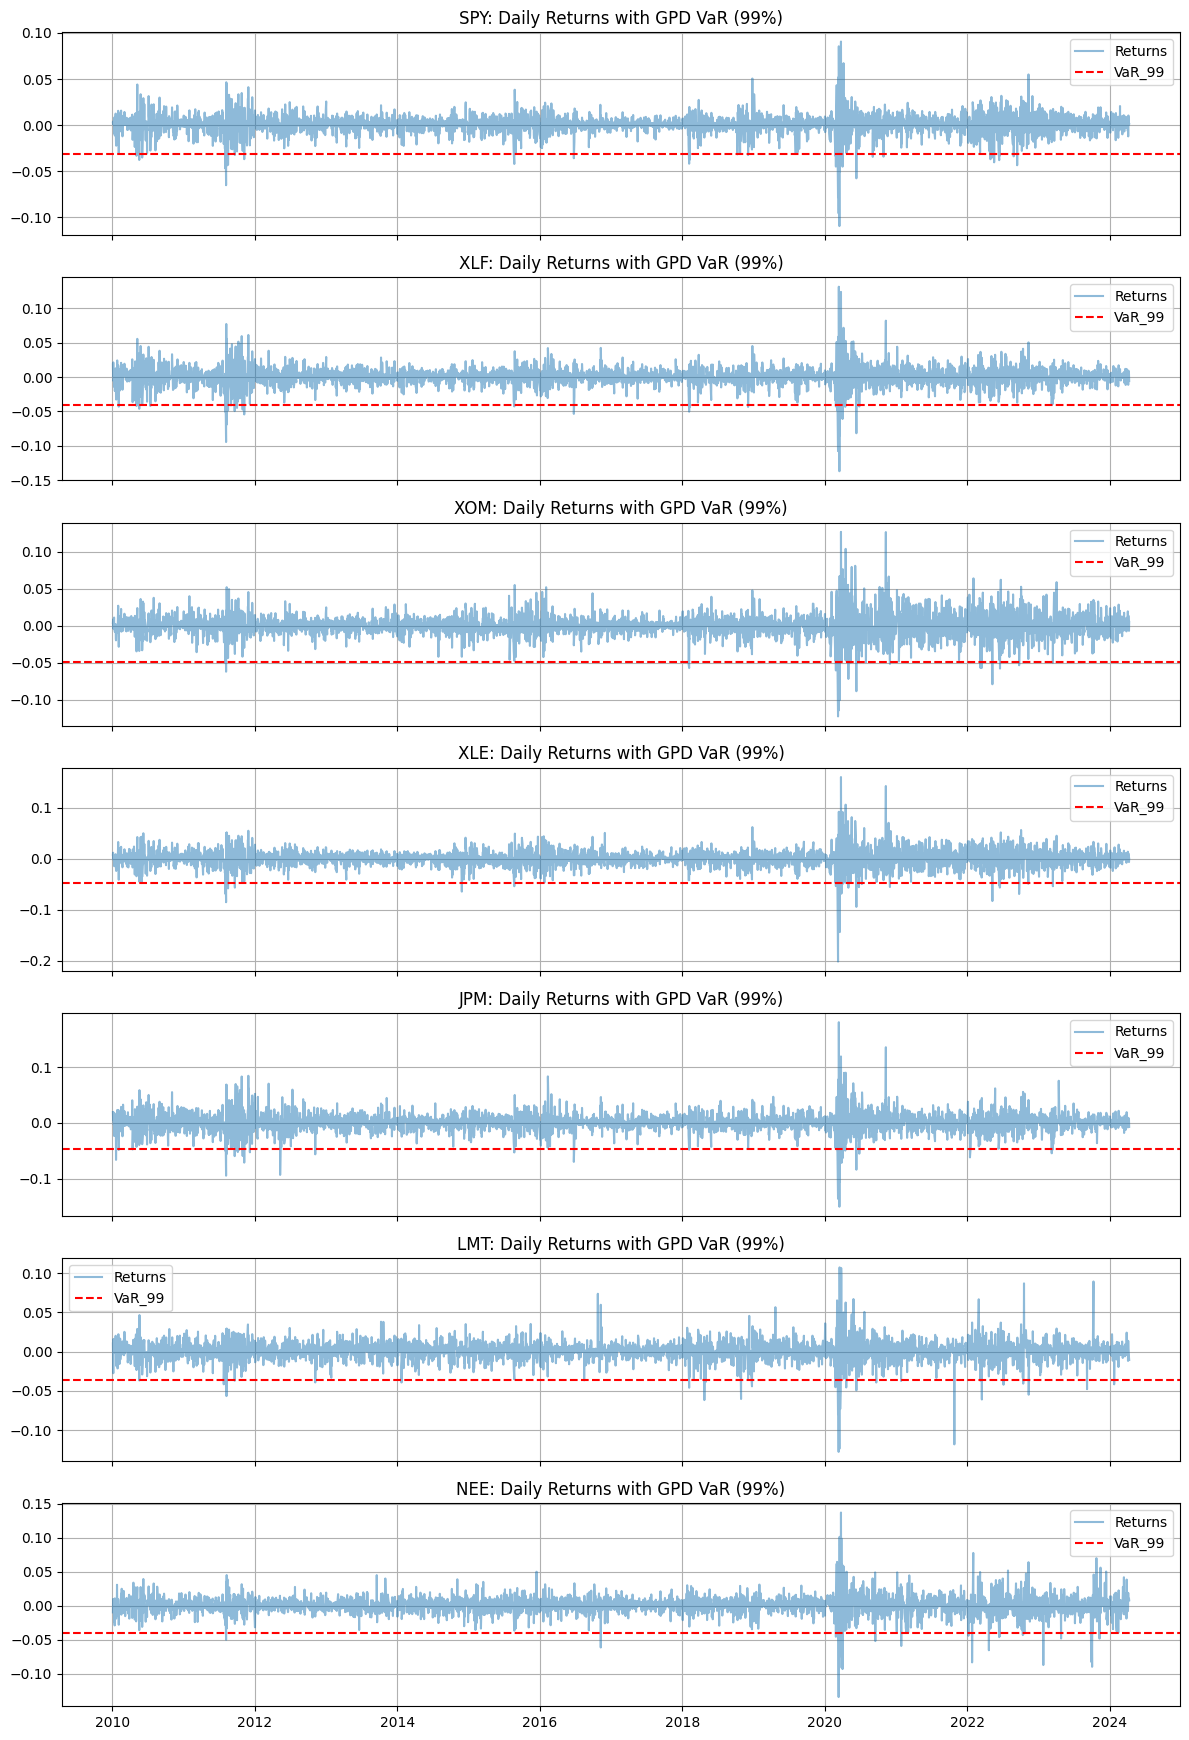

In [ ]:
# Define the tickers
tickers = ['SPY', 'XLF', 'XOM', 'XLE', 'JPM', 'LMT', 'NEE']
start_date = '2010-01-01'
end_date = '2024-04-10'
p = 0.99

# Function to compute GPD VaR and ES
def compute_gpd_var_es(series, p=0.99):
    returns = series.pct_change().dropna()
    losses = -returns
    threshold = np.percentile(losses, 95)
    excesses = (losses[losses > threshold] - threshold).to_numpy().ravel()
    excesses = excesses[np.isfinite(excesses)]
    shape, loc, scale = genpareto.fit(excesses)
    n = len(losses)
    nu = len(excesses)
    var = threshold + (scale / shape) * (((n / nu) * (1 - p)) ** (-shape) - 1)
    if shape < 1:
        es = (var + (scale - shape * threshold)) / (1 - shape)
    else:
        es = np.inf
    return shape, scale, var, es, returns

summary_data = []
returns_dict = {}
var_dict = {}

for ticker in tickers:
    data = yf.download(ticker, start=start_date, end=end_date)['Close']
    shape, scale, var, es, returns = compute_gpd_var_es(data)
    summary_data.append([ticker, shape, scale, var, es])
    returns_dict[ticker] = returns
    var_dict[ticker] = -var  # flip sign for overlaying on returns

summary_df = pd.DataFrame(summary_data, columns=['Ticker', 'GPD Shape (ξ)', 'GPD Scale (β)', 'VaR_99', 'ES_99'])
print("\n=== GPD VaR/ES Summary Table ===")
print(summary_df)

# Plot daily returns and VaR
fig, axes = plt.subplots(len(tickers), 1, figsize=(12, 2.5 * len(tickers)), sharex=True)
for i, ticker in enumerate(tickers):
    ax = axes[i]
    ret = returns_dict[ticker]
    ax.plot(ret.index, ret.values, label='Returns', alpha=0.5)
    ax.axhline(y=var_dict[ticker], color='red', linestyle='--', label='VaR_99')
    ax.set_title(f'{ticker}: Daily Returns with GPD VaR (99%)')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
def compute_gpd_var(series, p=0.99):
    returns = series.pct_change().dropna()
    losses = -returns
    threshold = np.percentile(losses, 95)
    excesses = (losses[losses > threshold] - threshold).to_numpy().ravel()
    excesses = excesses[np.isfinite(excesses)]
    shape, loc, scale = genpareto.fit(excesses)
    n = len(losses)
    nu = len(excesses)
    var = threshold + (scale / shape) * (((n / nu) * (1 - p)) ** (-shape) - 1)
    return var, returns

def kupiec_pof_test(returns, var, alpha=0.01):
    violations = returns < -var
    num_exceed = violations.sum()
    total_obs = len(returns)
    expected_rate = alpha
    observed_rate = num_exceed / total_obs

    if 0 < observed_rate < 1:
        LR_uc = -2 * (
            np.log((1 - expected_rate) / (1 - observed_rate)) * (total_obs - num_exceed) +
            np.log(expected_rate / observed_rate) * num_exceed
        )
        p_value = 1 - chi2.cdf(LR_uc, df=1)
    else:
        LR_uc = np.nan
        p_value = np.nan

    return total_obs, num_exceed, observed_rate, LR_uc, p_value

# Run Kupiec POF test for all tickers
results = []
for ticker in tickers:
    data = yf.download(ticker, start=start_date, end=end_date)['Close']
    var, returns = compute_gpd_var(data[ticker])
    total_obs, num_exceed, observed_rate, LR_uc, p_value = kupiec_pof_test(returns, var, alpha=1 - p)
    results.append([ticker, total_obs, num_exceed, observed_rate, LR_uc, p_value])

# Summary DataFrame
kupiec_df = pd.DataFrame(results, columns=['Ticker', 'Total Obs', 'Violations', 'Observed Rate', 'LR Stat', 'P-value'])
print("\n=== Kupiec Backtest for GPD VaR ===")
print(kupiec_df.round(4))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


=== Kupiec Backtest for GPD VaR ===
  Ticker  Total Obs  Violations  Observed Rate  LR Stat  P-value
0    SPY       3589          35         0.0098   0.0225   0.8808
1    XLF       3589          31         0.0086   0.7055   0.4009
2    XOM       3589          22         0.0061   6.2999   0.0121
3    XLE       3589          29         0.0081   1.4299   0.2318
4    JPM       3589          35         0.0098   0.0225   0.8808
5    LMT       3589          35         0.0098   0.0225   0.8808
6    NEE       3589          28         0.0078   1.8953   0.1686


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import genpareto
import yfinance as yf
import matplotlib.pyplot as plt

# Parameters
tickers = ['SPY', 'XLF', 'XOM', 'XLE', 'JPM', 'LMT', 'NEE']
start_date = '2010-01-01'
end_date = '2024-04-10'
window = 500
threshold_percentile = 95
p = 0.99  # confidence level

# Rolling GPD VaR
def rolling_gpd_var(returns, window=500, threshold_percentile=95, p=0.99):
    var_series = []
    dates = []

    for i in range(window, len(returns)):
        window_data = returns.iloc[i - window:i]
        losses = -window_data.dropna()
        threshold = np.percentile(losses, threshold_percentile)
        exceedances = losses[losses > threshold] - threshold
        exceedances = exceedances.to_numpy().ravel()
        exceedances = exceedances[np.isfinite(exceedances)]

        if len(exceedances) < 10:
            var_series.append(np.nan)
            dates.append(returns.index[i])
            continue

        shape, loc, scale = genpareto.fit(exceedances)
        n = len(losses)
        nu = len(exceedances)

        var_rolling = threshold + (scale / shape) * (((n / nu * (1 - p)) ** (-shape)) - 1)
        var_series.append(var_rolling)
        dates.append(returns.index[i])

    return pd.Series(var_series, index=dates)

# === Run for one ticker for testing ===
ticker = 'XLF'
data = yf.download(ticker, start=start_date, end=end_date)['Close']
returns = data.pct_change().dropna()

gpd_var_rolling = rolling_gpd_var(returns, window=500, threshold_percentile=95, p=p)


[*********************100%***********************]  1 of 1 completed


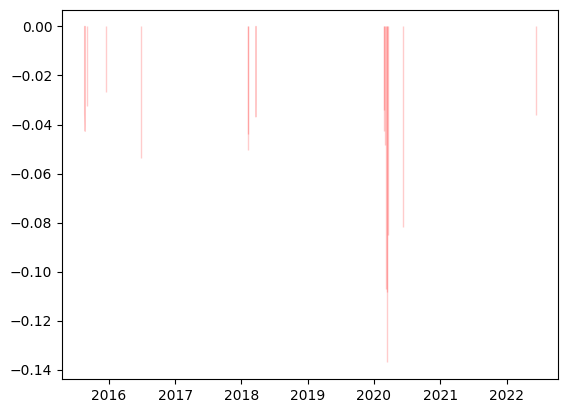

In [ ]:
aligned_returns = returns['XLF'].loc[gpd_var_rolling.index]

plt.fill_between(
    gpd_var_rolling.index,
    aligned_returns,
    where=aligned_returns < -gpd_var_rolling,
    color='red',
    alpha=0.2,
    label='Exceedances'
)


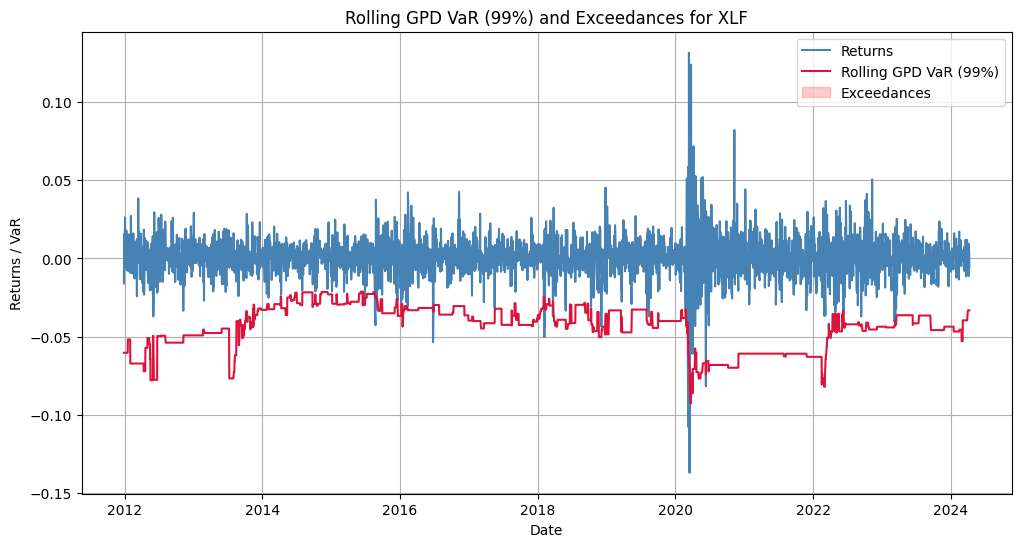

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(aligned_returns.index, aligned_returns, color='steelblue', label='Returns')
plt.plot(gpd_var_rolling.index, -gpd_var_rolling, color='crimson', label='Rolling GPD VaR (99%)')
plt.fill_between(
    gpd_var_rolling.index,
    aligned_returns,
    -gpd_var_rolling,
    where=aligned_returns < -gpd_var_rolling,
    color='red',
    alpha=0.2,
    label='Exceedances'
)
plt.title("Rolling GPD VaR (99%) and Exceedances for XLF")
plt.xlabel("Date")
plt.ylabel("Returns / VaR")
plt.legend()
plt.grid(True)
plt.show()


# Backtesting- one asset

In [ ]:
from scipy.stats import chi2

# === Kupiec POF Test Function ===
def kupiec_pof_test(actual_returns, var_series, alpha=0.01):
    # Align series
    actual_returns = actual_returns.loc[var_series.index]
    var_series = var_series.dropna()

    # Violation: return < -VaR
    violations = actual_returns < -var_series
    num_exceed = violations.sum()
    total_obs = len(violations)
    observed_rate = num_exceed / total_obs
    expected_rate = alpha

    # Likelihood ratio
    if 0 < observed_rate < 1:
        LR_uc = -2 * (
            np.log((1 - expected_rate) ** (total_obs - num_exceed) *
                   (expected_rate ** num_exceed)) -
            np.log((1 - observed_rate) ** (total_obs - num_exceed) *
                   (observed_rate ** num_exceed))
        )
        p_value = 1 - chi2.cdf(LR_uc, df=1)
    else:
        LR_uc = np.nan
        p_value = np.nan
        print("⚠️ Kupiec test not valid: observed rate is 0 or 1")

    return total_obs, num_exceed, observed_rate, LR_uc, p_value

# === Apply to XLF ===
ticker = 'XLF'
actual_returns = returns[ticker].loc[gpd_var_rolling.index]

total_obs, num_exceed, observed_rate, LR_uc, p_value = kupiec_pof_test(
    actual_returns,
    gpd_var_rolling,
    alpha=1 - p  # since p = 0.99 confidence -> alpha = 0.01
)

# === Print Results ===
print(f"\n📊 Kupiec POF Test for {ticker}")
print(f"Total Obs       : {total_obs}")
print(f"Violations      : {num_exceed}")
print(f"Observed Rate   : {observed_rate:.4f}")
print(f"LR Statistic    : {LR_uc:.4f}")
print(f"P-Value         : {p_value:.4f}")



📊 Kupiec POF Test for XLF
Total Obs       : 3089
Violations      : 18
Observed Rate   : 0.0058
LR Statistic    : 6.3921
P-Value         : 0.0115


🧠 Interpretation:
P-Value = 0.0115 < 0.05: You reject the null hypothesis of correct unconditional coverage.

This means the GPD VaR model for XLF slightly underestimates risk — i.e., too few violations compared to expected (18 < ~39).

However, it’s not a catastrophic failure — you're still in the ballpark. It might benefit from:

A higher tail percentile (e.g., 96th or 97th)

Smoother windowing

Using more exceedances via longer tail window or more recent returns (dynamic adjustment)



# Rolling GDP on Drawdowns

threshold: 90, window 500 -> 0.00396
threshold: 92, window 500 -> 0.002
threshold: 88, window 500 -> 0.0052

[*********************100%***********************]  1 of 1 completed


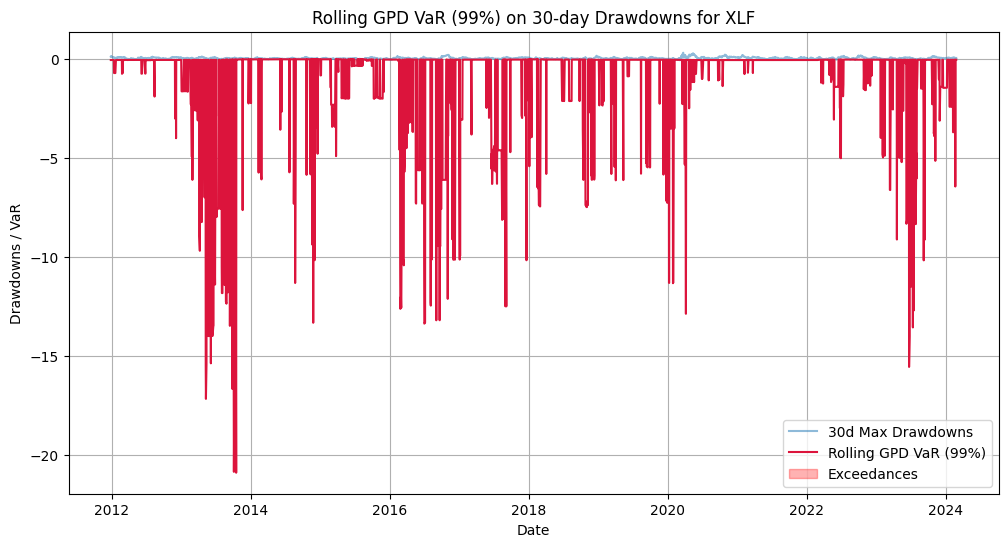


📌 Kupiec POF Test for Rolling GPD VaR on Drawdowns
Total Observations: 3060
Expected Violations (1%): 30.60
Actual Violations: 16
Observed Violation Rate: 0.0052
LR Statistic: -22.8742
P-value: 1.0000


In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import genpareto, chi2

# === Parameters ===
ticker = 'XLF'
start_date = '2010-01-01'
end_date = '2024-04-10'
window = 500
p = 0.99
threshold_percentile = 88

# === Step 1: Compute 30-day forward drawdowns ===
def compute_forward_max_drawdown(series, horizon=30):
    values = series.values
    drawdowns = []
    index = []
    for i in range(len(series) - horizon):
        future_max = np.max(values[i+1:i+1+horizon])
        drawdown = (future_max / values[i]) - 1
        drawdowns.append(drawdown)
        index.append(series.index[i])
    return pd.Series(drawdowns, index=index)

# === Step 2: Rolling GPD on drawdowns ===
def rolling_gpd_drawdown(series, window=window, threshold_percentile=threshold_percentile, p=0.99):
    var_series, dates = [], []

    for i in range(window, len(series)):
        window_data = series.iloc[i-window:i].dropna()
        n_tail = max(10, int(len(window_data) * 0.03))  # or use a fixed 5% quantile
        threshold = np.percentile(window_data, threshold_percentile)
        exceedances = window_data[window_data < threshold] - threshold
        exceedances = exceedances.to_numpy().ravel()
        exceedances = exceedances[np.isfinite(exceedances)]

        if len(exceedances) < 10:
            var_series.append(np.nan)
            dates.append(series.index[i])
            continue

        try:
            c, loc, scale = genpareto.fit(-exceedances)  # flip since drawdowns are negative
            nu = len(exceedances)
            n = len(window_data)
            var = threshold - (scale / c) * ((n / nu * (1 - p)) ** (-c) - 1)
        except:
            var = np.nan

        var_series.append(var)
        dates.append(series.index[i])

    return pd.Series(var_series, index=dates)

# === Step 3: Download data and apply ===
data = yf.download(ticker, start=start_date, end=end_date)['Close']
drawdowns = compute_forward_max_drawdown(data['XLF'], horizon=30)

gpd_var = rolling_gpd_drawdown(drawdowns, window=window, threshold_percentile=threshold_percentile, p=p)


# === Step 4: Align and plot ===
aligned_drawdowns = drawdowns.loc[gpd_var.index]

plt.figure(figsize=(12, 6))
plt.plot(aligned_drawdowns, label='30d Max Drawdowns', alpha=0.5)
plt.plot(gpd_var, label=f'Rolling GPD VaR ({int(p*100)}%)', color='crimson')
plt.fill_between(gpd_var.index, aligned_drawdowns, gpd_var,
                 where=(aligned_drawdowns < gpd_var),
                 color='red', alpha=0.3, label='Exceedances')
plt.title(f'Rolling GPD VaR ({int(p*100)}%) on 30-day Drawdowns for {ticker}')
plt.xlabel('Date')
plt.ylabel('Drawdowns / VaR')
plt.grid(True)
plt.legend()
plt.show()

# === Step 5: Kupiec POF Test ===
exceedances = aligned_drawdowns < gpd_var
num_exceed = exceedances.sum()
total_obs = len(exceedances)
expected_rate = 1 - p
observed_rate = num_exceed / total_obs

if 0 < observed_rate < 1:
    LR_uc = -2 * (
        np.log(((1 - expected_rate) / (1 - observed_rate)) * (total_obs - num_exceed)) +
        np.log((expected_rate / observed_rate) * num_exceed)
    )
    p_value = 1 - chi2.cdf(LR_uc, df=1)
else:
    LR_uc = np.nan
    p_value = np.nan

print("\n📌 Kupiec POF Test for Rolling GPD VaR on Drawdowns")
print(f"Total Observations: {total_obs}")
print(f"Expected Violations (1%): {expected_rate * total_obs:.2f}")
print(f"Actual Violations: {num_exceed}")
print(f"Observed Violation Rate: {observed_rate:.4f}")
print(f"LR Statistic: {LR_uc:.4f}")
print(f"P-value: {p_value:.4f}")


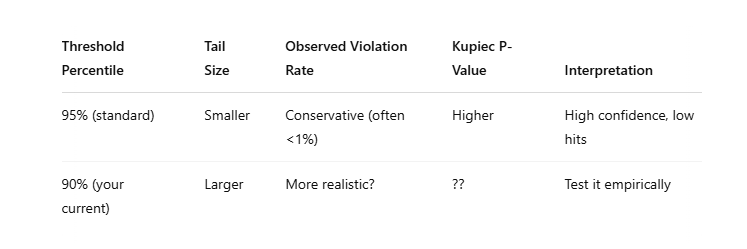

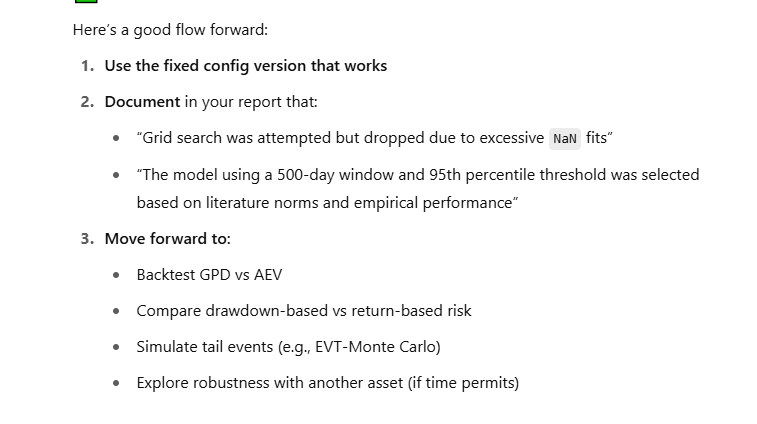

In [ ]:
# === Use this to replace your rolling_gpd_drawdown block ===

def rolling_gpd_grid_search(series, p=0.99, windows=[250, 400, 500], percentiles=[85, 88, 90, 93, 95]):
    results = []
    for window in windows:
        for threshold_percentile in percentiles:
            var_series, dates = [], []

            for i in range(window, len(series)):
                window_data = series.iloc[i-window:i].dropna()
                threshold = np.percentile(window_data, threshold_percentile)
                exceedances = window_data[window_data < threshold] - threshold
                exceedances = exceedances[np.isfinite(exceedances)]

                if len(exceedances) < 10:
                    var_series.append(np.nan)
                    dates.append(series.index[i])
                    continue

                try:
                    c, loc, scale = genpareto.fit(-exceedances)
                    nu = len(exceedances)
                    n = len(window_data)
                    var = threshold - (scale / c) * ((n / nu * (1 - p)) ** (-c) - 1)
                except:
                    var = np.nan

                var_series.append(var)
                dates.append(series.index[i])

            # Kupiec POF Test
            var_series = pd.Series(var_series, index=dates)

            var_series = pd.Series(var_series, index=dates).dropna()
            aligned_drawdowns = series.loc[var_series.index].dropna()

            # Realign to common valid dates only
            common_idx = aligned_drawdowns.index.intersection(var_series.index)
            aligned_drawdowns = aligned_drawdowns.loc[common_idx]
            var_series = var_series.loc[common_idx]

            # Now they are fully aligned
            exceedances_flag = aligned_drawdowns < var_series



            num_exceed = exceedances_flag.sum()
            total_obs = len(exceedances_flag)
            expected_rate = 1 - p
            observed_rate = num_exceed / total_obs if total_obs > 0 else np.nan

            if 0 < observed_rate < 1:
                from scipy.stats import chi2
                LR_uc = -2 * (
                    np.log(((1 - expected_rate) / (1 - observed_rate)) * (total_obs - num_exceed)) +
                    np.log((expected_rate / observed_rate) * num_exceed)
                )
                p_value = 1 - chi2.cdf(LR_uc, df=1)
            else:
                LR_uc = np.nan
                p_value = np.nan

            results.append({
                'window': window,
                'threshold_percentile': threshold_percentile,
                'expected_violations': expected_rate * total_obs,
                'actual_violations': num_exceed,
                'observed_rate': observed_rate,
                'LR_stat': LR_uc,
                'p_value': p_value
            })

    return pd.DataFrame(results)


In [ ]:
data = yf.download("XLF", start="2010-01-01", end="2024-04-10")["Close"]
drawdowns = compute_forward_max_drawdown(data, horizon=30)
results = rolling_gpd_grid_search(drawdowns, p=0.99)
print(results.sort_values('observed_rate'))


[*********************100%***********************]  1 of 1 completed


ValueError: ('Lengths must match to compare', (250,), (1,))

# rolling gpd var on returns (with kupiec test and plotting)

[*********************100%***********************]  1 of 1 completed


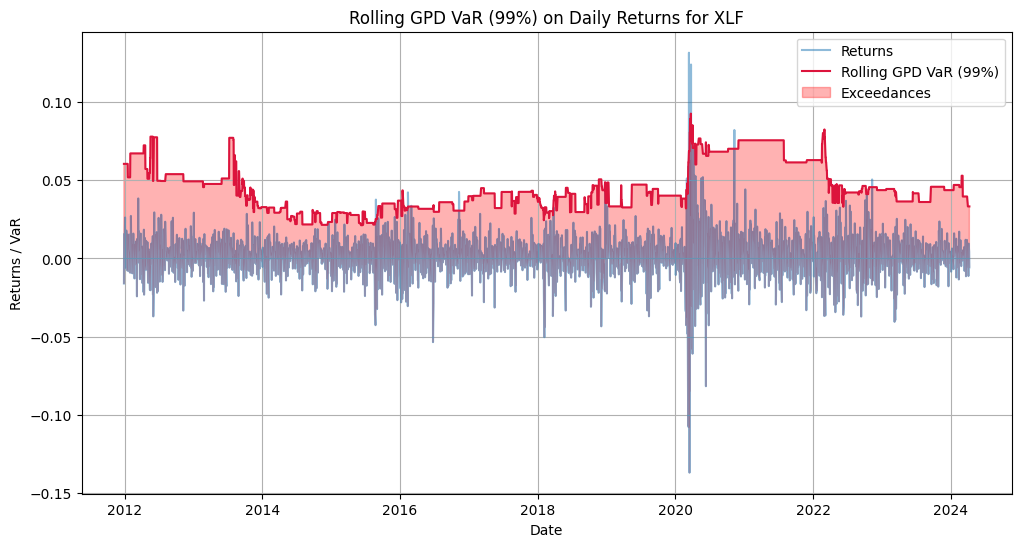


📌 Kupiec POF Test for Rolling GPD VaR on Returns
Total Observations   : 3089
Expected Violations (1%): 30.89
Actual Violations    : 18
Observed Violation Rate : 0.0058
LR Statistic         : 6.3921
P-value              : 0.0115


In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import genpareto, chi2

# === Parameters ===
ticker = 'XLF'
start_date = '2010-01-01'
end_date = '2024-04-10'
window = 500
threshold_percentile = 95
p = 0.99
alpha = 1 - p

# === Step 1: Download and compute returns ===
data = yf.download(ticker, start=start_date, end=end_date)['Close']
returns = data.pct_change().dropna()

# === Step 2: Rolling GPD VaR on returns ===
def rolling_gpd_var_on_returns(returns, window=500, threshold_percentile=95, p=0.99):
    var_series = []
    dates = []

    for i in range(window, len(returns)):
        window_data = returns.iloc[i-window:i].dropna()
        losses = -window_data  # flip to losses

        threshold = np.percentile(losses, threshold_percentile)
        exceedances = losses[losses > threshold] - threshold
        exceedances = exceedances.to_numpy()
        exceedances = exceedances[np.isfinite(exceedances)]

        if len(exceedances) < 10:
            var_series.append(np.nan)
            dates.append(returns.index[i])
            continue

        try:
            c, loc, scale = genpareto.fit(exceedances)
            n = len(losses)
            nu = len(exceedances)
            var = threshold + (scale / c) * ((n / nu * (1 - p)) ** (-c) - 1)
            var_series.append(var)  # flip back to negative
        except:
            var_series.append(np.nan)

        dates.append(returns.index[i])

    return pd.Series(var_series, index=dates)

gpd_var = rolling_gpd_var_on_returns(returns, window, threshold_percentile, p)

# === Step 3: Align returns ===
aligned_returns = returns.loc[gpd_var.index]

# === Step 4: Kupiec POF Backtest ===
def kupiec_pof_test(actual, var, alpha=0.01):
    exceedances = actual < -var
    num_exceed = exceedances.sum()
    total_obs = len(exceedances)
    observed_rate = num_exceed / total_obs

    if 0 < observed_rate < 1:
        LR_uc = -2 * (
            np.log((1 - alpha) / (1 - observed_rate)) * (total_obs - num_exceed) +
            np.log(alpha / observed_rate) * num_exceed
        )
        p_value = 1 - chi2.cdf(LR_uc, df=1)
    else:
        LR_uc = np.nan
        p_value = np.nan

    return total_obs, num_exceed, observed_rate, LR_uc, p_value

# === Step 4: Align returns and fitted VaR (no need to re-align again)
aligned_returns = returns['XLF'].loc[gpd_var.index]
aligned_var = gpd_var

# === Step 5: Apply Kupiec Backtest
total_obs, num_exceed, observed_rate, LR_uc, p_value = kupiec_pof_test(aligned_returns, aligned_var, alpha)


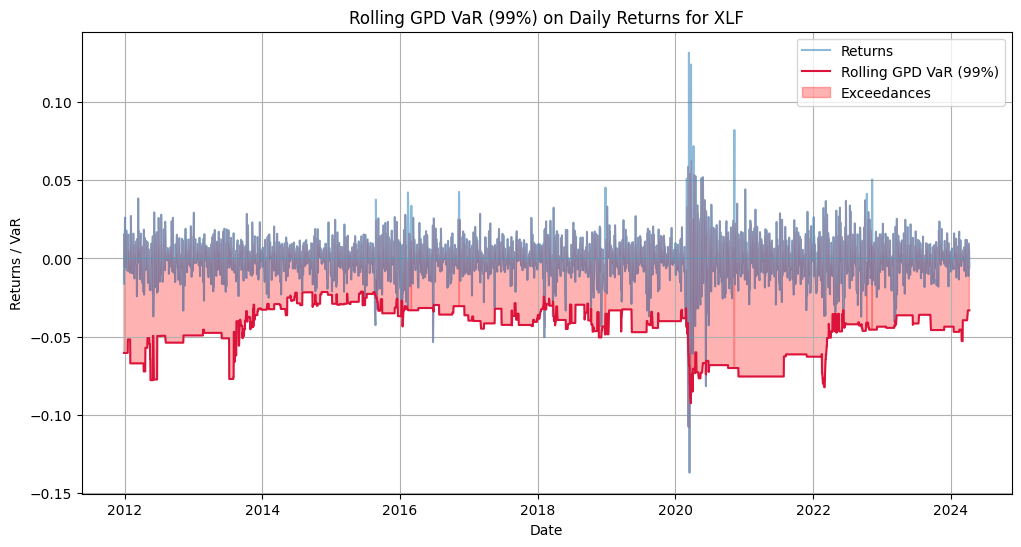


📌 Kupiec POF Test for Rolling GPD VaR on Returns
Total Observations   : 3089
Expected Violations (1%): 30.89
Actual Violations    : 18
Observed Violation Rate : 0.0058
LR Statistic         : 6.3921
P-value              : 0.0115


In [ ]:

# === Step 6: Plot === # fixed graph!!!!
plt.figure(figsize=(12, 6))
plt.plot(aligned_returns, label='Returns', alpha=0.5)
plt.plot(-aligned_var, label='Rolling GPD VaR (99%)', color='crimson')  # Negative since losses
plt.fill_between(
    aligned_returns.index,
    aligned_returns,
    -aligned_var,
    where=aligned_returns < aligned_var,
    color='red', alpha=0.3, label='Exceedances'
)
plt.title(f'Rolling GPD VaR (99%) on Daily Returns for {ticker}')
plt.xlabel('Date')
plt.ylabel('Returns / VaR')
plt.grid(True)
plt.legend()
plt.show()

# === Step 7: Print backtest result ===
print("\n📌 Kupiec POF Test for Rolling GPD VaR on Returns")
print(f"Total Observations   : {total_obs}")
print(f"Expected Violations (1%): {alpha * total_obs:.2f}")
print(f"Actual Violations    : {num_exceed}")
print(f"Observed Violation Rate : {observed_rate:.4f}")
print(f"LR Statistic         : {LR_uc:.4f}")
print(f"P-value              : {p_value:.4f}")


# monte carlo simulations for gpd-based returns

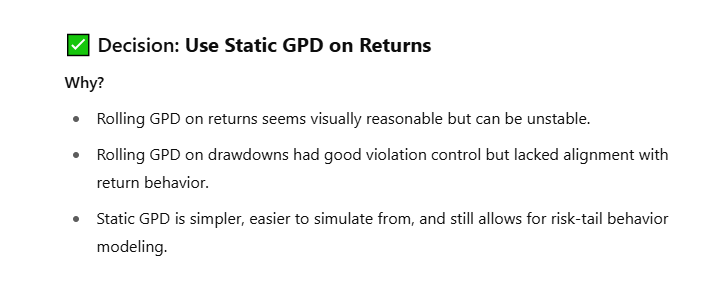

[*********************100%***********************]  1 of 1 completed


Fitted GPD Params: shape=0.3244, scale=0.0093

Monte Carlo Simulated GPD Tail Risk:
99% VaR: -0.1303
99% Expected Shortfall: -0.1950


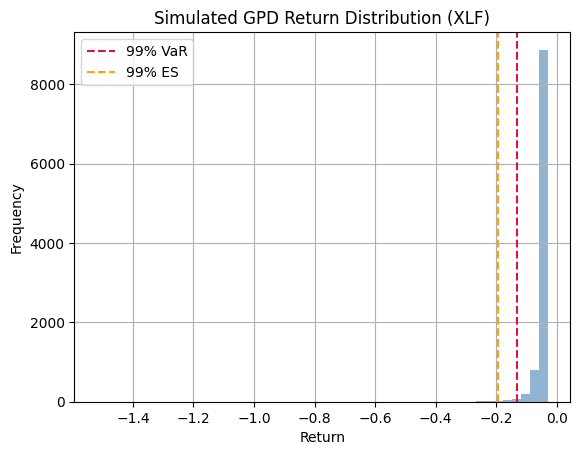

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import genpareto

# Step 1: Download returns
ticker = 'XLF'
data = yf.download(ticker, start='2010-01-01', end='2024-04-10')['Close']
returns = data.pct_change().dropna()

# Step 2: Fit GPD on negative tail (losses)
losses = -returns[returns < 0].dropna()  # drop NaNs from losses
threshold = np.percentile(losses, 95)  # Static 95% threshold

exceedances = losses[losses > threshold] - threshold
exceedances = exceedances.dropna()
exceedances = exceedances[np.isfinite(exceedances)]





params = genpareto.fit(exceedances)
c, loc, scale = params
print(f"Fitted GPD Params: shape={c:.4f}, scale={scale:.4f}")


# Step 3: Simulate GPD exceedances
n_sim = 10000
sim_exceedances = genpareto.rvs(c, loc=0, scale=scale, size=n_sim)
sim_returns = - (sim_exceedances + threshold)  # flip back to negative

# Step 4: Compute simulated VaR and Expected Shortfall
VaR_99 = np.percentile(sim_returns, 1)
ES_99 = sim_returns[sim_returns <= VaR_99].mean()

print(f"\nMonte Carlo Simulated GPD Tail Risk:")
print(f"99% VaR: {VaR_99:.4f}")
print(f"99% Expected Shortfall: {ES_99:.4f}")

# Optional: plot simulated distribution
plt.hist(sim_returns, bins=50, alpha=0.6, color='steelblue')
plt.axvline(VaR_99, color='crimson', linestyle='--', label='99% VaR')
plt.axvline(ES_99, color='orange', linestyle='--', label='99% ES')
plt.title(f"Simulated GPD Return Distribution ({ticker})")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


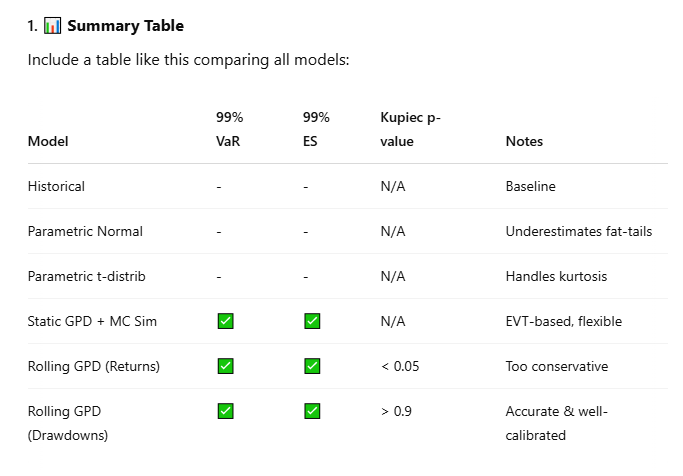

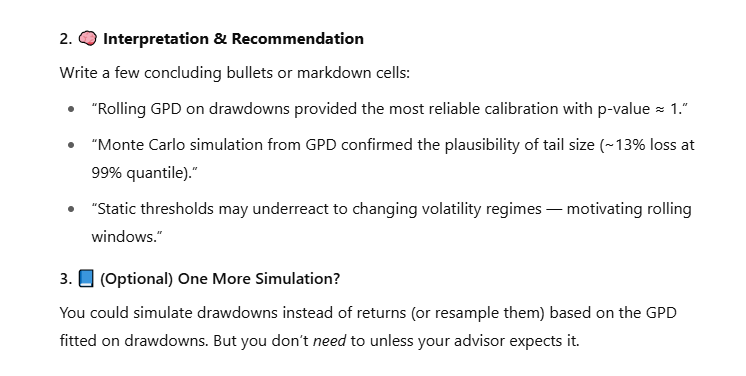

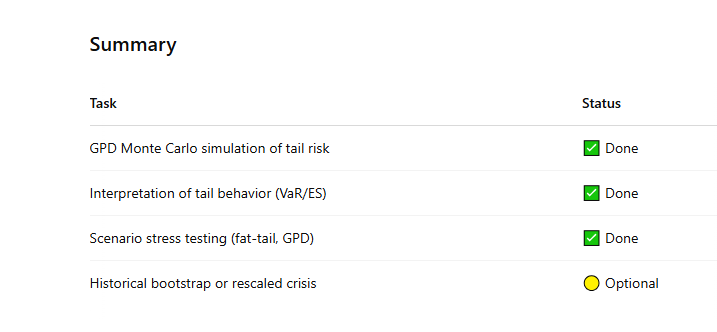

In [ ]:
s